In [401]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [402]:
#create a class for the liear regression model
class Linear_Regression():
  #initiate parameters
  def __init__(self,learning_rate,no_of_iterations):

    self.learning_rate=learning_rate
    self.no_of_iterations=no_of_iterations

  #fit the data to the model(Years of experience, salary)
  def fit(self, X, Y):

    #no of training & no of features
    #no.of rows and cols
    self.m, self.n=X.shape

    #initiate weights and biases
    self.w=np.zeros(self.n)
    self.b=0
    self.X=X
    self.Y=Y

    #implement gradient descent
    for i in range(self.no_of_iterations):
      self.update_weights()


  def update_weights(self,):

    Y_prediction=self.predict(self.X)

    #calculate the gradient
    dw=-(2*(self.X.T).dot(self.Y-Y_prediction))/self.m
    db=-2*np.sum(self.Y-Y_prediction)/self.m

    #update the weights and biases

    self.w=self.w-self.learning_rate*dw
    self.b=self.b-self.learning_rate*db

  def predict(self,X):

    return X.dot(self.w)+self.b


In [403]:
#load the data
salary=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MLModels/Linear Regression/salary_data.csv")
salary.head(10)

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


In [404]:
#no. of rows and column
salary.shape

(30, 2)

In [405]:
#split the features and target columns
X=salary.iloc[:,:-1].values
Y=salary.iloc[:,1].values
print(X)


[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]


In [406]:
print(Y)

[ 39343  46205  37731  43525  39891  56642  60150  54445  64445  57189
  63218  55794  56957  57081  61111  67938  66029  83088  81363  93940
  91738  98273 101302 113812 109431 105582 116969 112635 122391 121872]


In [407]:
#split into train and test data
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.33,random_state=2)

In [408]:
#train the model
#create an instace of the linear regression model
model=Linear_Regression(learning_rate=0.02, no_of_iterations=1000)


In [409]:

model.fit(X_train,Y_train)

In [410]:
#print the parameters
print('weight=',model.w[0])
print('Bias=', model.b)

weight= 9514.400999035135
Bias= 23697.406507136307


In [411]:
test_data_predict=model.predict(X_test)

In [412]:
print(test_data_predict)

[ 36066.12780588  34163.24760607  66512.21100279  58900.69020357
  91249.65360029  80783.81250135 101715.49469922  52240.60950424
  42726.20850521  88395.33330058]


Text(0, 0.5, 'Salary')

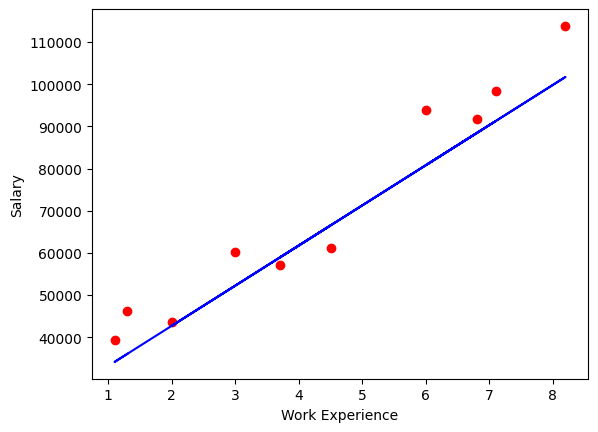

In [414]:
#viualize predicted vs actual values
plt.scatter(X_test,Y_test,color='red')
plt.plot(X_test,test_data_predict,color='blue')
plt.xlabel('Work Experience')
plt.ylabel('Salary')